In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import matplotlib as mpl


The following  function gives the scalar surface self-energy

$
\Sigma^r(E) = \frac{t_c^2}{2t_{\text{lead}}^2} \left[ E - i \sqrt{4t_{\text{lead}}^2 - E^2} \right]
$

inside the lead band $|E| < 2t_{\text{lead}}$.

However, this model is **spinful**, so the lead self-energy acting on the contact site must be a $ 2 \times 2 $ spin matrix:

$
\Sigma_p^r(E) = \Sigma^r(E) \sigma_0 =
\begin{pmatrix}
\Sigma^r(E) & 0 \\
0 & \Sigma^r(E)
\end{pmatrix}.
$

The reason is that the nonmagnetic leads treat spin-up and spin-down identically.

So your scalar function can remain unchanged, but later we use it as:

* se_scalar = selfenergy(E, t_couple=tc, t_lead=tl)

* se_spin = se_scalar * np.eye(2, dtype=complex)

In [2]:
#cell 1: lead self-energy:

"""
the leads are not explicitly added to the Hamiltonian matrix.

Instead, they are incorporated through the self-energies $Σ_L$ and $Σ_R$.

That is why, in the code, we see se = selfenergy(en, t_couple=tc, t_lead=tl)
"""



def selfenergy(energy, t_couple=1.0, t_lead=1.0):  #when no value is supplied, use t_lead=1.0
    """Compute the selfenergy of a semi-infinite lead

    Parameters
    ----------
    energy: energy at which we probe the system.
    tc : float
        Coupling between the lead and the main scattering region.
    tl : float
        Coupling within the lead (hopping inside the semi-infinite lead itself)

    Returns
    -------
    selfenergy : float
    """

    rad = 4*t_lead**2 - energy**2
    coef = t_couple**2 / (2*t_lead**2)

    if (rad > 0):
        se = coef * (energy - 1j*np.sqrt(rad))
    else:
        se = coef * (energy - np.sign(energy)*np.sqrt(-rad))

    return se

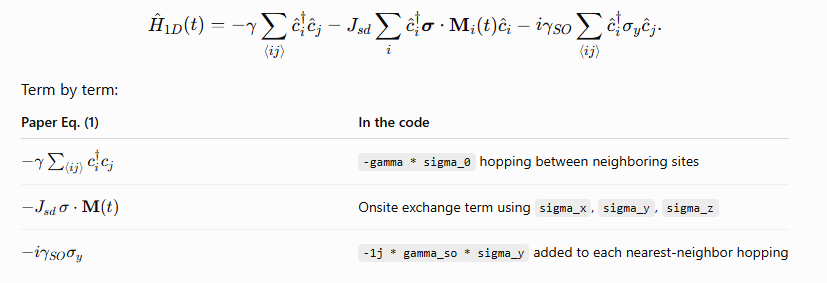

In [5]:
# Cell 2: Fourier components of the 1D FM Hamiltonian

import numpy as np

EV_OVER_H_TO_UA = 38.74  # (e/h) × 1 eV in microampere

# Pauli matrices
sigma_0 = np.eye(2, dtype=complex)

sigma_x = np.array([
    [0, 1],
    [1, 0]
], dtype=complex)

sigma_y = np.array([
    [0, -1j],
    [1j, 0]
], dtype=complex)

sigma_z = np.array([
    [1, 0],
    [0, -1]
], dtype=complex)


def fm_fourier_component(
    m,
    n_sites=9,
    gamma=1.0,
    Jsd=0.1,
    gamma_so=0.1,
    theta=np.deg2rad(20.0)
):
    """
    Construct the Fourier component H_m of the periodically driven
    1D ferromagnetic Hamiltonian.

    Basis:
        |1,up>, |1,down>, |2,up>, |2,down>, ...

    The convention is:
        H(t) = sum_m exp(-i m omega_0 t) H_m
    """

    dim = 2 * n_sites
    Hm = np.zeros((dim, dim), dtype=complex)

    # ---------------------------------------------------------
    # Onsite exchange contribution
    # ---------------------------------------------------------

    # Static z-component belongs to H_0
    if m == 0:
        onsite_static = -Jsd * np.cos(theta) * sigma_z

        for i in range(n_sites):
            sl = slice(2*i, 2*i + 2)
            Hm[sl, sl] += onsite_static

    # Time-dependent transverse exchange components
    #
    # sigma_x cos(wt) + sigma_y sin(wt)
    # = sigma_- exp(+iwt) + sigma_+ exp(-iwt)
    #
    # With H(t) = sum_m exp(-imwt) H_m:
    # H_{+1} contains sigma_+
    # H_{-1} contains sigma_-

    sigma_plus = 0.5 * (sigma_x + 1j * sigma_y)
    sigma_minus = 0.5 * (sigma_x - 1j * sigma_y)

    if m == 1:
        onsite_plus = -Jsd * np.sin(theta) * sigma_plus

        for i in range(n_sites):
            sl = slice(2*i, 2*i + 2)
            Hm[sl, sl] += onsite_plus

    if m == -1:
        onsite_minus = -Jsd * np.sin(theta) * sigma_minus

        for i in range(n_sites):
            sl = slice(2*i, 2*i + 2)
            Hm[sl, sl] += onsite_minus

    # ---------------------------------------------------------
    # Static nearest-neighbour hopping and Rashba SOC
    # Both belong only to H_0
    # ---------------------------------------------------------

    if m == 0:
        hopping_forward = -gamma * sigma_0 - 1j * gamma_so * sigma_y

        for i in range(n_sites - 1):
            sli = slice(2*i, 2*i + 2)
            slj = slice(2*(i+1), 2*(i+1) + 2)

            Hm[sli, slj] += hopping_forward
            Hm[slj, sli] += hopping_forward.conj().T

    return Hm

In [6]:
H0 = fm_fourier_component(0)
Hp = fm_fourier_component(1)
Hm = fm_fourier_component(-1)

print("H0 Hermiticity error:",
      np.linalg.norm(H0 - H0.conj().T))

print("H_-1 - H_+1 dagger:",
      np.linalg.norm(Hm - Hp.conj().T))

H0 Hermiticity error: 0.0
H_-1 - H_+1 dagger: 0.0


In [8]:
# Cell 3: Build the Floquet Hamiltonian H_F for the 1D FM chain

def build_floquet_H_FM(
    n_sites=9,
    gamma=1.0,
    Jsd=0.1,
    gamma_so=0.1,
    theta=np.deg2rad(20.0),
    Nf=6
):
    """
    Assemble the Fourier components H_m of the 1D FM Hamiltonian
    into the Floquet Hamiltonian H_F.

    Basis within each Floquet block:
        |1,up>, |1,down>, ..., |n_sites,up>, |n_sites,down>

    Floquet indices:
        -Nph, ..., 0, ..., +Nph
    """

    floquet_indices = np.arange(-Nf, Nf + 1)

    # Each physical site has two spin states
    dim_e = 2 * n_sites
    nph_tot = len(floquet_indices)

    # Total Floquet-space dimension
    dim_F = nph_tot * dim_e

    HF = np.zeros((dim_F, dim_F), dtype=complex)

    for a, ma in enumerate(floquet_indices):
        for b, mb in enumerate(floquet_indices):

            # Required Fourier component for this Floquet block
            q = mb - ma

            block = fm_fourier_component(
                q,
                n_sites=n_sites,
                gamma=gamma,
                Jsd=Jsd,
                gamma_so=gamma_so,
                theta=theta
            )

            row = slice(a * dim_e, (a + 1) * dim_e)
            col = slice(b * dim_e, (b + 1) * dim_e)

            HF[row, col] = block

    return HF, floquet_indices

In [10]:
#from paper:
#convergence in n is achieved by ensuring that each Nth harmonic satisfies ...
#This typically requires the use of nmax ≤6 , so Nf=6





HF, floquet_indices = build_floquet_H_FM(
    n_sites=9,
    gamma=1.0,
    Jsd=0.1,
    gamma_so=0.1,
    theta=np.deg2rad(20.0),
    Nf=6
)

print("floquet_indices:", floquet_indices)
print("Floquet Hamiltonian shape:", HF.shape)

print(
    "Floquet Hermiticity error:",
    np.linalg.norm(HF - HF.conj().T)
)

floquet_indices: [-6 -5 -4 -3 -2 -1  0  1  2  3  4  5  6]
Floquet Hamiltonian shape: (234, 234)
Floquet Hermiticity error: 0.0


In [11]:
# Cell 4:
# Floquet retarded Green function for the 1D FM system
#each site has two spin states;
#the left lead couples to both spins of site 1;
#the right lead couples to both spins of site 9
#The important physical difference from the Rice–Mele code is that
#each lead now couples to a two-dimensional spin subspace, rather than to one scalar orbital.

def floquet_Gr_FM(
    E,
    omega_ev=0.01,
    n_sites=9,
    Nf=6,
    gamma=1.0,
    Jsd=0.1,
    gamma_so=0.1,
    theta=np.deg2rad(20.0),
    t_lead=1.0,
    t_couple=1.0,
    eta=1e-12
):
    """
    Construct the Floquet retarded Green function for the
    1D ferromagnetic central region.

    Each physical site has two spin states.

    Parameters
    ----------
    E : float
        Base energy, later chosen as the Fermi energy E_F = 0.

    omega_ev : float
        Driving energy hbar*omega_0 in units of gamma.

    Nf : int
        Floquet truncation: m = -Nf, ..., +Nf.

    Returns
    -------
    Gr : ndarray
        Full retarded Green function in Floquet-Sambe space.

    GammaL, GammaR : ndarray
        Lead broadening matrices in Floquet-Sambe space.

    floquet_indices : ndarray
        Retained Floquet indices.
    """

    # Build the Floquet Hamiltonian
    HF, floquet_indices = build_floquet_H_FM(
        n_sites=n_sites,
        gamma=gamma,
        Jsd=Jsd,
        gamma_so=gamma_so,
        theta=theta,
        Nf=Nf
    )

    # Electronic dimension of one Floquet block
    dim_e = 2 * n_sites

    # Total Floquet dimension
    dim_F = HF.shape[0]

    Ibig = np.eye(dim_F, dtype=complex)

    SigmaL = np.zeros((dim_F, dim_F), dtype=complex)
    SigmaR = np.zeros((dim_F, dim_F), dtype=complex)

    GammaL = np.zeros((dim_F, dim_F), dtype=complex)
    GammaR = np.zeros((dim_F, dim_F), dtype=complex)

    Omega = np.zeros((dim_F, dim_F), dtype=complex)

    # Spin identity matrix because the leads are nonmagnetic
    spin_identity = np.eye(2, dtype=complex)

    for a, m in enumerate(floquet_indices):

        # Location of Floquet block m
        sl = slice(a * dim_e, (a + 1) * dim_e)

        # Energy of sideband m
        Em = E + m * omega_ev

        # Scalar self-energy of a semi-infinite 1D lead
        se = selfenergy(
            Em,
            t_couple=t_couple,
            t_lead=t_lead
        )

        # Scalar level broadening
        gam = 1j * (se - np.conj(se))

        # Convert scalar lead quantities into 2x2 spin matrices
        se_spin = se * spin_identity
        gam_spin = gam * spin_identity

        # -------------------------------------------------
        # Left lead: coupled to both spins of site 1
        # -------------------------------------------------
        left_contact = slice(sl.start, sl.start + 2)

        SigmaL[left_contact, left_contact] = se_spin
        GammaL[left_contact, left_contact] = gam_spin

        # -------------------------------------------------
        # Right lead: coupled to both spins of site n_sites
        # -------------------------------------------------
        right_contact = slice(sl.stop - 2, sl.stop)

        SigmaR[right_contact, right_contact] = se_spin
        GammaR[right_contact, right_contact] = gam_spin

        # Floquet energy shift m*hbar*omega_0
        Omega[sl, sl] = (
            m * omega_ev * np.eye(dim_e, dtype=complex)
        )

    Sigma = SigmaL + SigmaR

    # Equation (7):
    # Gr = [E + Omega - HF - Sigma]^(-1)
    Gr = np.linalg.inv(
        (E + 1j * eta) * Ibig
        + Omega
        - HF
        - Sigma
    )

    return Gr, GammaL, GammaR, floquet_indices

In [12]:
Gr, GammaL, GammaR, floquet_indices = floquet_Gr_FM(
    E=0.0,
    omega_ev=0.01,
    n_sites=9,
    Nf=6,
    gamma=1.0,
    Jsd=0.1,
    gamma_so=0.1,
    theta=np.deg2rad(20.0),
    t_lead=1.0,
    t_couple=1.0
)

print("Gr shape:", Gr.shape)

print(
    "GammaL Hermiticity error:",
    np.linalg.norm(GammaL - GammaL.conj().T)
)

print(
    "GammaR Hermiticity error:",
    np.linalg.norm(GammaR - GammaR.conj().T)
)

Gr shape: (234, 234)
GammaL Hermiticity error: 0.0
GammaR Hermiticity error: 0.0


In [13]:
# Cell 5:
# Extract contact Green-function blocks for the spinful 1D FM chain

def extract_contact_Gr_FM(Gr, floquet_indices, n_sites, m):
    """
    Extract the four 2x2 spin contact Green-function blocks

        G^r_pp'(E_m, E)

    from the full Floquet retarded Green function.

    Parameters
    ----------
    Gr : ndarray
        Full Floquet retarded Green-function matrix.

    floquet_indices : ndarray
        Floquet-sector labels, for example [-6, ..., 0, ..., +6].

    n_sites : int
        Number of physical sites in the FM chain.

    m : int
        Outgoing Floquet sector, so E_m = E + m*hbar*omega_0.

    Returns
    -------
    contact_Gr : dict
        Dictionary containing the 2x2 spin blocks
        GLL, GLR, GRL, and GRR.
    """

    floquet_indices = np.asarray(floquet_indices)

    if 0 not in floquet_indices:
        raise ValueError(
            "The Floquet truncation must contain sector m=0."
        )

    if m not in floquet_indices:
        raise ValueError(
            f"Floquet sector m={m} is outside the truncation "
            f"{floquet_indices.tolist()}."
        )

    # Position of incoming sector 0 and outgoing sector m
    a0 = np.where(floquet_indices == 0)[0][0]
    am = np.where(floquet_indices == m)[0][0]

    # Each Floquet block has 2*n_sites states because of spin
    dim_e = 2 * n_sites

    # Contact spin subspaces inside one Floquet block
    # Left contact = site 1, both spins
    # Right contact = site n_sites, both spins
    row_L = slice(am * dim_e, am * dim_e + 2)
    row_R = slice(
        am * dim_e + 2 * (n_sites - 1),
        am * dim_e + 2 * n_sites
    )

    col_L = slice(a0 * dim_e, a0 * dim_e + 2)
    col_R = slice(
        a0 * dim_e + 2 * (n_sites - 1),
        a0 * dim_e + 2 * n_sites
    )

    GLL = Gr[row_L, col_L]
    GLR = Gr[row_L, col_R]
    GRL = Gr[row_R, col_L]
    GRR = Gr[row_R, col_R]

    return {
        "LL": GLL,
        "LR": GLR,
        "RL": GRL,
        "RR": GRR
    }

In [14]:
contact_Gr = extract_contact_Gr_FM(
    Gr,
    floquet_indices,
    n_sites=9,
    m=1
)

for key, value in contact_Gr.items():
    print(key, value.shape)

    #Rice–Mele contact Green functions were scalars.
#Here each contact Green function is a 2×2 matrix in spin space.

LL (2, 2)
LR (2, 2)
RL (2, 2)
RR (2, 2)


In [15]:
"""
Extract the Floquet contact Green-function blocks
G^r_pp'(E_m, E)

from the full spinful retarded Floquet Green function G^r.

The full Floquet Green function contains:
    - all Floquet sectors
    - all 9 physical sites
    - both spin states on every site

This routine extracts the four 2x2 spin blocks connecting the
incoming Floquet sector m = 0 to an outgoing Floquet sector m.

The extracted quantities are:

    G_LL^r(E_m,E) : left-to-left reflection block
    G_LR^r(E_m,E) : right-to-left transmission block
    G_RL^r(E_m,E) : left-to-right transmission block
    G_RR^r(E_m,E) : right-to-right reflection block

Each quantity is a 2x2 matrix in spin space:

        [ up -> up      down -> up   ]
        [ up -> down    down -> down ]

These contact Green-function blocks will be used to construct
the Floquet scattering matrices S_LL, S_LR, S_RL, and S_RR.
"""


# Extract contact Green-function blocks for m = -1, 0, +1
for m in [-1, 0, 1]:

    Gc = extract_contact_Gr_FM(
        Gr=Gr,
        floquet_indices=floquet_indices,
        n_sites=9,
        m=m
    )

    print(f"\nm = {m}")

    print("G_LL =")
    print(Gc["LL"])

    print("G_LR =")
    print(Gc["LR"])

    print("G_RL =")
    print(Gc["RL"])

    print("G_RR =")
    print(Gc["RR"])


m = -1
G_LL =
[[ 0.00174642-7.14932214e-05j  0.0052992 -3.36965072e-05j]
 [-0.00232006+9.77515540e-05j -0.00174548+9.42877150e-05j]]
G_LR =
[[-0.02651576-0.00401224j  0.05809889-0.00115713j]
 [ 0.00656897-0.00013154j -0.02634145+0.00506571j]]
G_RL =
[[0.02651576+0.00401224j 0.05809889-0.00115713j]
 [0.00656897-0.00013154j 0.02634145-0.00506571j]]
G_RR =
[[-0.00174642+7.14932214e-05j  0.0052992 -3.36965072e-05j]
 [-0.00232006+9.77515540e-05j  0.00174548-9.42877150e-05j]]

m = 0
G_LL =
[[ 0.00818606-4.94297259e-01j -0.00938321-2.75387352e-17j]
 [-0.00938321+1.31513724e-16j -0.00818606-4.94297259e-01j]]
G_LR =
[[ 1.77088393e-01-0.30558493j -1.38777878e-17-0.34665422j]
 [-3.46944695e-17+0.34665422j -1.77088393e-01-0.30558493j]]
G_RL =
[[ 1.77088393e-01-0.30558493j -2.08166817e-17+0.34665422j]
 [ 5.20417043e-18-0.34665422j -1.77088393e-01-0.30558493j]]
G_RR =
[[ 0.00818606-4.94297259e-01j  0.00938321-2.01390554e-17j]
 [ 0.00938321-1.33898968e-17j -0.00818606-4.94297259e-01j]]

m = 1
G_LL =

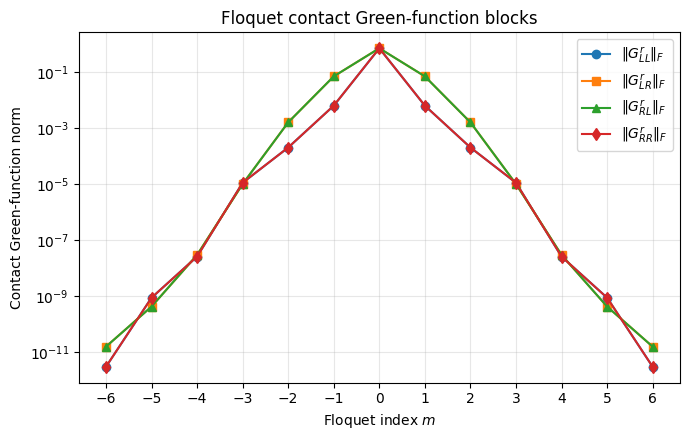

In [16]:
# Diagnostic plot of contact Green-function strength versus Floquet index



norm_LL = []
norm_LR = []
norm_RL = []
norm_RR = []

for m in floquet_indices:

    Gc = extract_contact_Gr_FM(
        Gr=Gr,
        floquet_indices=floquet_indices,
        n_sites=9,
        m=m
    )

    norm_LL.append(np.linalg.norm(Gc["LL"], ord="fro"))
    norm_LR.append(np.linalg.norm(Gc["LR"], ord="fro"))
    norm_RL.append(np.linalg.norm(Gc["RL"], ord="fro"))
    norm_RR.append(np.linalg.norm(Gc["RR"], ord="fro"))

plt.figure(figsize=(7, 4.5))

plt.semilogy(floquet_indices, norm_LL, "o-", label=r"$\|G_{LL}^r\|_F$")
plt.semilogy(floquet_indices, norm_LR, "s-", label=r"$\|G_{LR}^r\|_F$")
plt.semilogy(floquet_indices, norm_RL, "^-", label=r"$\|G_{RL}^r\|_F$")
plt.semilogy(floquet_indices, norm_RR, "d-", label=r"$\|G_{RR}^r\|_F$")

plt.xlabel("Floquet index $m$")
plt.ylabel("Contact Green-function norm")
plt.title("Floquet contact Green-function blocks")
plt.xticks(floquet_indices)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# Cell 6:
# Construct spinful Floquet scattering matrices from Eq. (12)

def gamma_scalar(E, t_couple=1.0, t_lead=1.0):
    """
    Scalar lead broadening for one spin channel:

        Gamma(E) = i [Sigma^r(E) - Sigma^a(E)]
                 = -2 Im Sigma^r(E)
    """

    se = selfenergy(
        E,
        t_couple=t_couple,
        t_lead=t_lead
    )

    gam = np.real(1j * (se - np.conj(se)))

    # Remove tiny negative values due to numerical roundoff
    return max(gam, 0.0)


def build_contact_S_FM(
    Gcontact,
    E,
    m,
    omega_ev,
    t_lead=1.0,
    t_couple=1.0
):
    """
    Build the four 2x2 spin Floquet scattering matrices

        S_pp'(E_m, E)

    for one outgoing Floquet sector m.

    Here:
        E_m = E + m*hbar*omega_0

    Gcontact must contain the 2x2 blocks:
        LL, LR, RL, RR
    """

    Em = E + m * omega_ev

    # Incoming and outgoing lead broadenings
    Gamma_in_scalar = gamma_scalar(
        E,
        t_couple=t_couple,
        t_lead=t_lead
    )

    Gamma_out_scalar = gamma_scalar(
        Em,
        t_couple=t_couple,
        t_lead=t_lead
    )

    # Since the leads are nonmagnetic:
    # Gamma = gamma_scalar * I_2
    sqrt_Gamma_in = np.sqrt(Gamma_in_scalar) * np.eye(2, dtype=complex)
    sqrt_Gamma_out = np.sqrt(Gamma_out_scalar) * np.eye(2, dtype=complex)

    # Identity term exists only when p = p' and m = 0
    delta_m0 = 1.0 if m == 0 else 0.0
    Ispin = np.eye(2, dtype=complex)

    # Eq. (12)
    SLL = (
        delta_m0 * Ispin
        - 1j * sqrt_Gamma_out @ Gcontact["LL"] @ sqrt_Gamma_in
    )

    SRR = (
        delta_m0 * Ispin
        - 1j * sqrt_Gamma_out @ Gcontact["RR"] @ sqrt_Gamma_in
    )

    SLR = (
        -1j * sqrt_Gamma_out @ Gcontact["LR"] @ sqrt_Gamma_in
    )

    SRL = (
        -1j * sqrt_Gamma_out @ Gcontact["RL"] @ sqrt_Gamma_in
    )

    return {
        "LL": SLL,
        "LR": SLR,
        "RL": SRL,
        "RR": SRR
    }

In [18]:
for m in [-1, 0, 1]:

    Gc = extract_contact_Gr_FM(
        Gr=Gr,
        floquet_indices=floquet_indices,
        n_sites=9,
        m=m
    )

    Sc = build_contact_S_FM(
        Gcontact=Gc,
        E=0.0,
        m=m,
        omega_ev=0.01,
        t_lead=1.0,
        t_couple=1.0
    )

    print(f"\nm = {m}")

    print("S_LL =")
    print(Sc["LL"])

    print("S_LR =")
    print(Sc["LR"])

    print("S_RL =")
    print(Sc["RL"])

    print("S_RR =")
    print(Sc["RR"])


m = -1
S_LL =
[[-1.42985549e-04-0.00349281j -6.73925931e-05-0.01059833j]
 [ 1.95501886e-04+0.00464008j  1.88574251e-04+0.00349095j]]
S_LR =
[[-0.00802443+0.05303118j -0.00231424-0.11619705j]
 [-0.00026309-0.01313785j  0.01013135+0.05268257j]]
S_RL =
[[ 0.00802443-0.05303118j -0.00231424-0.11619705j]
 [-0.00026309-0.01313785j -0.01013135-0.05268257j]]
S_RR =
[[ 1.42985549e-04+0.00349281j -6.73925931e-05-0.01059833j]
 [ 1.95501886e-04+0.00464008j -1.88574251e-04-0.00349095j]]

m = 0
S_LL =
[[ 1.14054821e-02-0.01637212j -5.50774704e-17+0.01876642j]
 [ 2.63027447e-16+0.01876642j  1.14054821e-02+0.01637212j]]
S_LR =
[[-0.61116986-3.54176786e-01j -0.69330844+2.77555756e-17j]
 [ 0.69330844+6.93889390e-17j -0.61116986+3.54176786e-01j]]
S_RL =
[[-0.61116986-3.54176786e-01j  0.69330844+4.16333634e-17j]
 [-0.69330844-1.04083409e-17j -0.61116986+3.54176786e-01j]]
S_RR =
[[ 1.14054821e-02-0.01637212j -4.02781107e-17-0.01876642j]
 [-2.67797937e-17-0.01876642j  1.14054821e-02+0.01637212j]]

m = 1
S_

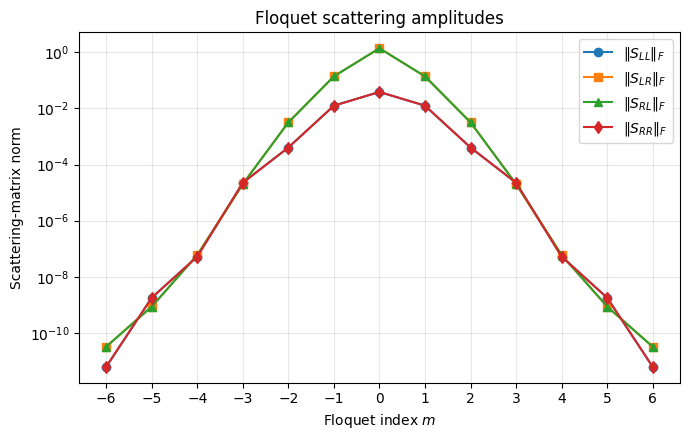

In [19]:
# Diagnostic plot of Floquet scattering-matrix strength versus Floquet index

import numpy as np
import matplotlib.pyplot as plt

norm_SLL = []
norm_SLR = []
norm_SRL = []
norm_SRR = []

E = 0.0
omega_ev = 0.01
n_sites = 9

for m in floquet_indices:

    # Extract contact Green-function blocks
    Gc = extract_contact_Gr_FM(
        Gr=Gr,
        floquet_indices=floquet_indices,
        n_sites=n_sites,
        m=m
    )

    # Build scattering matrices
    Sc = build_contact_S_FM(
        Gcontact=Gc,
        E=E,
        m=m,
        omega_ev=omega_ev,
        t_lead=1.0,
        t_couple=1.0
    )

    # Frobenius norm of each 2x2 spin block
    norm_SLL.append(np.linalg.norm(Sc["LL"], ord="fro"))
    norm_SLR.append(np.linalg.norm(Sc["LR"], ord="fro"))
    norm_SRL.append(np.linalg.norm(Sc["RL"], ord="fro"))
    norm_SRR.append(np.linalg.norm(Sc["RR"], ord="fro"))


plt.figure(figsize=(7, 4.5))

plt.semilogy(
    floquet_indices,
    norm_SLL,
    "o-",
    label=r"$\|S_{LL}\|_F$"
)

plt.semilogy(
    floquet_indices,
    norm_SLR,
    "s-",
    label=r"$\|S_{LR}\|_F$"
)

plt.semilogy(
    floquet_indices,
    norm_SRL,
    "^-",
    label=r"$\|S_{RL}\|_F$"
)

plt.semilogy(
    floquet_indices,
    norm_SRR,
    "d-",
    label=r"$\|S_{RR}\|_F$"
)

plt.xlabel("Floquet index $m$")
plt.ylabel("Scattering-matrix norm")
plt.title("Floquet scattering amplitudes")
plt.xticks(floquet_indices)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# Cell 7:
# Floquet scattering-matrix unitarity test

def check_floquet_unitarity_FM(
    Gr,
    floquet_indices,
    E=0.0,
    omega_ev=0.01,
    n_sites=9,
    t_lead=1.0,
    t_couple=1.0
):
    """
    Check

        sum_{p=L,R} sum_m S_{p p'}^ dagger(m) S_{p p'}(m) = I_2

    separately for incoming lead p' = L and p' = R.
    """

    U_in_L = np.zeros((2, 2), dtype=complex)
    U_in_R = np.zeros((2, 2), dtype=complex)

    for m in floquet_indices:

        # Contact Green-function blocks
        Gc = extract_contact_Gr_FM(
            Gr=Gr,
            floquet_indices=floquet_indices,
            n_sites=n_sites,
            m=m
        )

        # Contact scattering matrices
        Sc = build_contact_S_FM(
            Gcontact=Gc,
            E=E,
            m=m,
            omega_ev=omega_ev,
            t_lead=t_lead,
            t_couple=t_couple
        )

        # Incoming from left:
        # outgoing can be left or right
        U_in_L += (
            Sc["LL"].conj().T @ Sc["LL"]
            + Sc["RL"].conj().T @ Sc["RL"]
        )

        # Incoming from right:
        # outgoing can be left or right
        U_in_R += (
            Sc["LR"].conj().T @ Sc["LR"]
            + Sc["RR"].conj().T @ Sc["RR"]
        )

    Ispin = np.eye(2, dtype=complex)

    error_L = np.linalg.norm(U_in_L - Ispin, ord="fro")
    error_R = np.linalg.norm(U_in_R - Ispin, ord="fro")

    print("Unitarity matrix for incoming lead L:")
    print(U_in_L)

    print("\nUnitarity error for incoming lead L:")
    print(error_L)

    print("\nUnitarity matrix for incoming lead R:")
    print(U_in_R)

    print("\nUnitarity error for incoming lead R:")
    print(error_R)

    return U_in_L, U_in_R, error_L, error_R

In [23]:
U_L, U_R, error_L, error_R = check_floquet_unitarity_FM(
    Gr=Gr,
    floquet_indices=floquet_indices,
    E=0.0,
    omega_ev=0.01,
    n_sites=9,
    t_lead=1.0,
    t_couple=1.0
)

Unitarity matrix for incoming lead L:
[[ 1.0000000e+00+0.00000000e+00j -4.2120642e-18-1.05669443e-16j]
 [-4.2120642e-18+1.05669443e-16j  1.0000000e+00+0.00000000e+00j]]

Unitarity error for incoming lead L:
1.2675670438328155e-11

Unitarity matrix for incoming lead R:
[[ 1.00000000e+00+0.00000000e+00j -2.95896157e-16+2.50302807e-16j]
 [-2.95896157e-16-2.50302807e-16j  1.00000000e+00+0.00000000e+00j]]

Unitarity error for incoming lead R:
1.2677319058286353e-11


The matrices are equal to $I_2$ which is
up to numerical roundoff, and the errors are only 1.3× $10^{-11}$
which is far smaller than the paper’s convergence tolerance $10^{-2}$

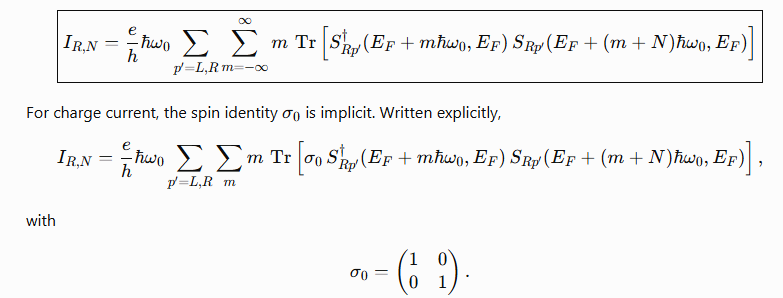

In [24]:
# Cell 8:
# Equation (11): N-th charge-current harmonic in the right lead

def harmonic_charge_current_R_FM(
    N,
    omega_ev=0.01,
    n_sites=9,
    Nf=6,
    gamma=1.0,
    Jsd=0.1,
    gamma_so=0.1,
    theta=np.deg2rad(20.0),
    EF=0.0,
    t_lead=1.0,
    t_couple=1.0
):
    r"""
    Compute the N-th harmonic of the charge current flowing into
    the right lead using Eq. (11):

        I_{R,N} = (e/h) * hbar*omega_0
                  * sum_{p'=L,R} sum_m
                    m Tr[
                        S_{Rp'}^\dagger(E_F+m*hbar*omega_0, E_F)
                        S_{Rp'}(E_F+(m+N)*hbar*omega_0, E_F)
                    ]

    For charge current, sigma_alpha in Eq. (11) is replaced by
    the 2x2 spin identity, leaving an ordinary spin trace.

    Returns
    -------
    I_natural : complex
        Current harmonic in units of e*gamma/h,
        when all energies are measured in units of gamma.

    I_microamp : complex
        Current in microampere if gamma = 1 eV.
        For another physical gamma, multiply this value by gamma in eV.
    """

    if N < 0:
        raise ValueError("Use a non-negative harmonic order N.")

    if N > 2 * Nf:
        raise ValueError(
            f"N={N} cannot be represented using Nf={Nf}. "
            f"The largest difference between retained sectors is {2*Nf}."
        )

    # ---------------------------------------------------------
    # 1. Floquet retarded Green function at E = E_F
    # ---------------------------------------------------------
    Gr, GammaL, GammaR, floquet_indices = floquet_Gr_FM(
        E=EF,
        omega_ev=omega_ev,
        n_sites=n_sites,
        Nf=Nf,
        gamma=gamma,
        Jsd=Jsd,
        gamma_so=gamma_so,
        theta=theta,
        t_lead=t_lead,
        t_couple=t_couple
    )

    # ---------------------------------------------------------
    # 2. Construct and store all S matrices S_pp'(m)
    # ---------------------------------------------------------
    S_by_m = {}

    for m in floquet_indices:
        m = int(m)

        Gc = extract_contact_Gr_FM(
            Gr=Gr,
            floquet_indices=floquet_indices,
            n_sites=n_sites,
            m=m
        )

        Sc = build_contact_S_FM(
            Gcontact=Gc,
            E=EF,
            m=m,
            omega_ev=omega_ev,
            t_lead=t_lead,
            t_couple=t_couple
        )

        S_by_m[m] = Sc

    # ---------------------------------------------------------
    # 3. Equation (11)
    # ---------------------------------------------------------
    total = 0.0 + 0.0j

    for m in floquet_indices:
        m = int(m)
        mpN = m + N

        # Eq. (11) needs both sectors m and m+N
        if mpN not in S_by_m:
            continue

        # p' = L:
        # incoming from L, outgoing into R
        term_from_L = np.trace(
            S_by_m[m]["RL"].conj().T
            @ S_by_m[mpN]["RL"]
        )

        # p' = R:
        # incoming from R, outgoing into R
        term_from_R = np.trace(
            S_by_m[m]["RR"].conj().T
            @ S_by_m[mpN]["RR"]
        )

        # Essential factor m appearing explicitly in Eq. (11)
        total += m * (term_from_L + term_from_R)

    # In units of e*gamma/h when omega_ev is expressed in units of gamma
    I_natural = omega_ev * total

    # If gamma = 1 eV, convert (e/h)*eV to microampere
    I_microamp = EV_OVER_H_TO_UA * I_natural

    return I_natural, I_microamp

In [36]:
results = []

for N in range(1, 13):

    I_natural, I_uA = harmonic_charge_current_R_FM(
        N=N,
        omega_ev=0.01,
        n_sites=9,
        Nf=6,
        gamma=1.0,
        Jsd=0.1,
        gamma_so=0.1,
        theta=np.deg2rad(20.0),
        EF=0.0,
        t_lead=1.0,
        t_couple=1.0
    )

    results.append(abs(I_natural))

    print(
        f"N = {N:2d}, "
        f"I_RN = {I_natural:.6e} [e gamma / h], "
        f"|I_RN| = {abs(I_natural):.6e}"
    )

N =  1, I_RN = 6.716628e-08+1.595855e-07j [e gamma / h], |I_RN| = 1.731440e-07
N =  2, I_RN = 5.265996e-09-7.263240e-08j [e gamma / h], |I_RN| = 7.282304e-08
N =  3, I_RN = -2.668771e-09+1.722197e-10j [e gamma / h], |I_RN| = 2.674322e-09
N =  4, I_RN = 1.763385e-11-7.393803e-11j [e gamma / h], |I_RN| = 7.601174e-11
N =  5, I_RN = -7.089548e-13-1.639044e-13j [e gamma / h], |I_RN| = 7.276549e-13
N =  6, I_RN = 6.263141e-15-1.259014e-14j [e gamma / h], |I_RN| = 1.406196e-14
N =  7, I_RN = 5.060693e-15-8.795422e-15j [e gamma / h], |I_RN| = 1.014742e-14
N =  8, I_RN = -2.225144e-16-1.640569e-16j [e gamma / h], |I_RN| = 2.764549e-16
N =  9, I_RN = -4.609464e-19+3.620712e-19j [e gamma / h], |I_RN| = 5.861460e-19
N = 10, I_RN = -1.795485e-20-1.768572e-20j [e gamma / h], |I_RN| = 2.520241e-20
N = 11, I_RN = 7.371341e-23-1.006649e-22j [e gamma / h], |I_RN| = 1.247681e-22
N = 12, I_RN = -2.763030e-24-4.367115e-24j [e gamma / h], |I_RN| = 5.167788e-24


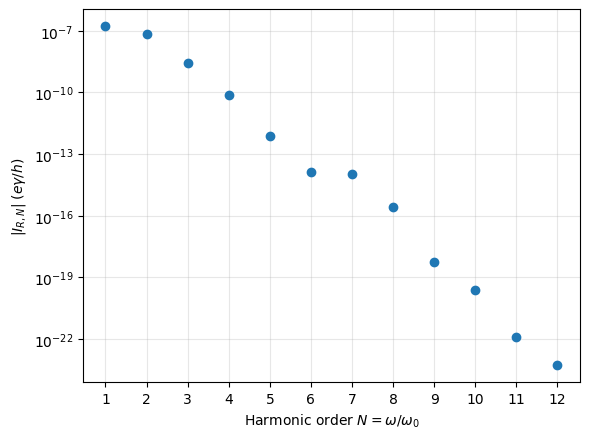

In [37]:
N_values = np.arange(1, 13)

plt.figure(figsize=(6, 4.5))

plt.semilogy(
    N_values,
    results,
    "o"
)

plt.xlabel(r"Harmonic order $N=\omega/\omega_0$")
plt.ylabel(r"$|I_{R,N}| \; (e\gamma/h)$")
plt.xticks(N_values)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

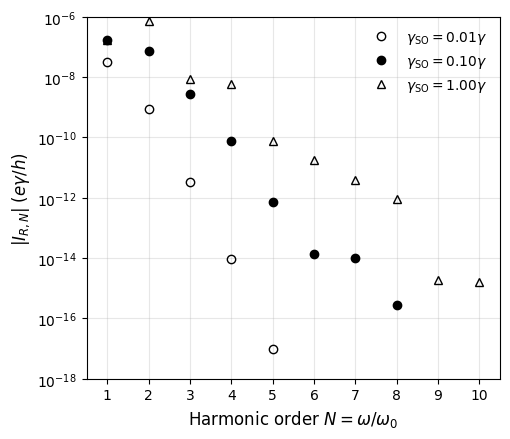

In [38]:


# -----------------------------
# Parameters
# -----------------------------
N_values = np.arange(1, 11)

gamma_so_values = [0.01, 0.10, 1.00]

markers = ['o', 'o', '^']
labels = [
    r'$\gamma_{\rm SO}=0.01\gamma$',
    r'$\gamma_{\rm SO}=0.10\gamma$',
    r'$\gamma_{\rm SO}=1.00\gamma$'
]

facecolors = ['none', 'black', 'none']

plt.figure(figsize=(5.2,4.5))

for gamma_so, marker, label, fc in zip(
        gamma_so_values,
        markers,
        labels,
        facecolors):

    Ivals = []

    for N in N_values:

        I_RN, _ = harmonic_charge_current_R_FM(
            N=N,
            omega_ev=0.01,
            n_sites=9,
            Nf=6,
            gamma=1.0,
            Jsd=0.1,
            gamma_so=gamma_so,
            theta=np.deg2rad(20.0),
            EF=0.0,
            t_lead=1.0,
            t_couple=1.0
        )

        Ivals.append(abs(I_RN))

    plt.semilogy(
        N_values,
        Ivals,
        linestyle='None',
        marker=marker,
        markersize=6,
        markerfacecolor=fc,
        markeredgecolor='black',
        label=label
    )

# -----------------------------
# Formatting
# -----------------------------
plt.xlim(0.5, 10.5)
plt.ylim(1e-18, 1e-6)          # Match the paper
plt.xticks(np.arange(1,11))

plt.xlabel(r'Harmonic order $N=\omega/\omega_0$', fontsize=12)
plt.ylabel(r'$|I_{R,N}| \;(e\gamma/h)$', fontsize=12)

plt.grid(True, which='both', alpha=0.3)
plt.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

Figure 4, panel c form the paper

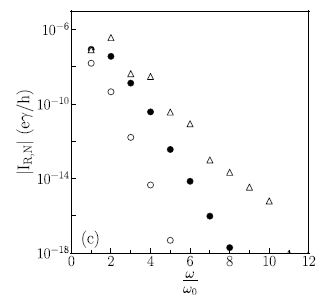

In [40]:
for Nf_test in [4, 5, 6, 7]:

    vals = []

    # Maximum allowed harmonic for this truncation
    N_max_allowed = min(10, 2 * Nf_test)

    for N in range(1, N_max_allowed + 1):

        I_RN, _ = harmonic_charge_current_R_FM(
            N=N,
            omega_ev=0.01,
            n_sites=9,
            Nf=Nf_test,
            gamma=1.0,
            Jsd=0.1,
            gamma_so=0.1,
            theta=np.deg2rad(20.0),
            EF=0.0,
            t_lead=1.0,
            t_couple=1.0
        )

        vals.append(abs(I_RN))

    print(f"\nNf = {Nf_test}")
    print(f"Computed harmonics: N = 1 to {N_max_allowed}")
    print(vals)


Nf = 4
Computed harmonics: N = 1 to 8
[np.float64(1.7314398800091473e-07), np.float64(7.282304371863211e-08), np.float64(2.674323226263044e-09), np.float64(7.544601982312543e-11), np.float64(2.0758192719192627e-11), np.float64(1.4465562205706587e-12), np.float64(8.752601944856741e-15), np.float64(1.2990484890012e-16)]

Nf = 5
Computed harmonics: N = 1 to 10
[np.float64(1.7314398800214648e-07), np.float64(7.28230438411913e-08), np.float64(2.6743224551722825e-09), np.float64(7.601111920990106e-11), np.float64(7.028337488741039e-13), np.float64(8.592336363317059e-13), np.float64(1.5093360567604688e-15), np.float64(2.576310316535203e-16), np.float64(4.248392819250377e-19), np.float64(2.976780038542719e-20)]

Nf = 6
Computed harmonics: N = 1 to 10
[np.float64(1.7314398800188257e-07), np.float64(7.28230438412001e-08), np.float64(2.674322456441489e-09), np.float64(7.601174414448645e-11), np.float64(7.276548507172591e-13), np.float64(1.4061956941851081e-14), np.float64(1.0147416242759877e-14)

In [41]:
Nf_tests = [6, 7, 8, 9, 10]
N_values = np.arange(1, 11)

all_results = {}

for Nf_test in Nf_tests:

    vals = []

    for N in N_values:

        I_RN, _ = harmonic_charge_current_R_FM(
            N=int(N),
            omega_ev=0.01,
            n_sites=9,
            Nf=Nf_test,
            gamma=1.0,
            Jsd=0.1,
            gamma_so=0.1,
            theta=np.deg2rad(20.0),
            EF=0.0,
            t_lead=1.0,
            t_couple=1.0
        )

        vals.append(abs(I_RN))

    all_results[Nf_test] = np.array(vals)

    print(f"\nNf = {Nf_test}")
    for N, value in zip(N_values, vals):
        print(f"N={N:2d}: {value:.6e}")


Nf = 6
N= 1: 1.731440e-07
N= 2: 7.282304e-08
N= 3: 2.674322e-09
N= 4: 7.601174e-11
N= 5: 7.276549e-13
N= 6: 1.406196e-14
N= 7: 1.014742e-14
N= 8: 2.764549e-16
N= 9: 5.861460e-19
N=10: 2.520241e-20

Nf = 7
N= 1: 1.731440e-07
N= 2: 7.282304e-08
N= 3: 2.674322e-09
N= 4: 7.601174e-11
N= 5: 7.276604e-13
N= 6: 1.415262e-14
N= 7: 1.834464e-16
N= 8: 7.963591e-17
N= 9: 5.621622e-19
N=10: 3.330965e-20

Nf = 8
N= 1: 1.731440e-07
N= 2: 7.282304e-08
N= 3: 2.674322e-09
N= 4: 7.601174e-11
N= 5: 7.276604e-13
N= 6: 1.415275e-14
N= 7: 1.907465e-16
N= 8: 3.904302e-18
N= 9: 9.731830e-19
N=10: 3.818001e-20

Nf = 9
N= 1: 1.731440e-07
N= 2: 7.282304e-08
N= 3: 2.674322e-09
N= 4: 7.601174e-11
N= 5: 7.276604e-13
N= 6: 1.415275e-14
N= 7: 1.907472e-16
N= 8: 3.908720e-18
N= 9: 3.586448e-20
N=10: 1.707852e-20

Nf = 10
N= 1: 1.731440e-07
N= 2: 7.282304e-08
N= 3: 2.674322e-09
N= 4: 7.601174e-11
N= 5: 7.276604e-13
N= 6: 1.415275e-14
N= 7: 1.907472e-16
N= 8: 3.908745e-18
N= 9: 3.694980e-20
N=10: 6.357472e-22


In [42]:
for Nf_test in Nf_tests[1:]:

    previous = all_results[Nf_test - 1]
    current = all_results[Nf_test]

    relative_error = np.abs(current - previous) / np.maximum(
        np.abs(previous),
        1e-30
    )

    print(f"\nRelative change: Nf={Nf_test-1} -> Nf={Nf_test}")

    for N, error in zip(N_values, relative_error):
        status = "converged" if error < 1e-2 else "not converged"

        print(
            f"N={N:2d}: error={error:.3e}  {status}"
        )


Relative change: Nf=6 -> Nf=7
N= 1: error=1.001e-12  converged
N= 2: error=6.852e-14  converged
N= 3: error=2.645e-14  converged
N= 4: error=1.076e-09  converged
N= 5: error=7.594e-06  converged
N= 6: error=6.448e-03  converged
N= 7: error=9.819e-01  not converged
N= 8: error=7.119e-01  not converged
N= 9: error=4.092e-02  not converged
N=10: error=3.217e-01  not converged

Relative change: Nf=7 -> Nf=8
N= 1: error=8.346e-13  converged
N= 2: error=7.342e-14  converged
N= 3: error=8.537e-14  converged
N= 4: error=1.238e-13  converged
N= 5: error=2.776e-10  converged
N= 6: error=8.669e-06  converged
N= 7: error=3.979e-02  not converged
N= 8: error=9.510e-01  not converged
N= 9: error=7.311e-01  not converged
N=10: error=1.462e-01  not converged

Relative change: Nf=8 -> Nf=9
N= 1: error=2.160e-13  converged
N= 2: error=5.870e-14  converged
N= 3: error=7.841e-14  converged
N= 4: error=2.551e-14  converged
N= 5: error=2.498e-15  converged
N= 6: error=1.066e-09  converged
N= 7: error=3.740